<a href="https://colab.research.google.com/github/sambee5/data-science-coursework/blob/main/Unit6/SamarthBUnit6ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install bambi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.9/218.9 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.6/164.6 kB 4.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import arviz as az
import pymc as pm
import graphviz as gv
import matplotlib.pyplot as plt
import seaborn as sns
import bambi as bmb

# Unit 6 Exercises: Is my model good?

#### Over and Under fitting, Model Visualization, and Model/Variable Selection Concepts

These exercises are meant to get you to think about the model and variable selection process, and consider how we determine if a model is "good".

**Task1**:

Does elpd_loo mean anything if we only have one model?

Using elpd_loo doesn't mean much if we only have one model. It's purpose is to serve as a tool and metric to analyze which model performs better, which entails comparison. Without another model to compare to, elpd_loo is not needed.

**Task2**:

Describe overfitting, in the context of this course

Overfitting in models occur when it is able to generalize it's predictions to the real world. This happens because it's made detailed patterns that may only pertain to the certain dataset being used, and would therefore be significantly thrown off when new, similar data is introduced.

**Task3**:

How do we mitigate overfitting?

We mitigate overfitting by giving the model enough priors to "gain and understanding of the context." It's like teaching a baby to walk-- it's only effective when you give them enough experience walking on differeant surfaces to truly be able to walk anywhere. We are able to identify which priors we need to use by making a causal diagram, which reiterates their importance in both project planning and execution.

I'd like to emphasize "enough" priors more. It is better to have an accurate model with less assumptions/parameters since it reduces overfitting. This is synonymous with keeping someone open minded. The model shouldn't be too specific about the world because it needs to be able to adapt to a wide variety of data in order to be useful.

**Task4**:

How do we mitigate underfitting?

Underfitting happens when the model doesn't have enough information to work with, which appears when there is a lack of informative priors. A quick and easy way to prevent underfitting in GLMs is by including informative priors.

**Task5**:

Why would we want more than one predictor in a model?

Having more than one predictor in a model is useful because it allows you to create a diverse model that can take a variety of inputs, which allow it to output a more realistic prediction based on all of the assumptions we create the model with. For example, if we wanted to create a model which predicts house prices, having multiple predictors such as sq footage, number of bathrooms, etc. would be much more informative and increase accuracy than just number of bathrooms itself.

**Task6**:

Can we have too many predictors? How would we know?

Yes! It's possible to have too many predictors. While having many may seem like a good thing, it can lead to the model overfitting, which restricts it's predictive ability. Having too many predictors inhibits the models ability to generalize data beyond what it's given (the dataset), which doesn't make it a particularly useful model.

**Task7**:

What is variable selection, and how does it work?

Variable selection is trivialized with bambi and causal diagrams. Variable selection is the process of selecting priors and likelihoods to use in your model, which is super important since it has everything to do with model accuracy. First, you have to  make a causal diagram, implementing all the variables that have an effect on your prediction. To find what is interesting to predict, we can use bambi's inbuilt pair_plot function which plots all of the possible scatterplots with the x and y axes. We use all of the priors in our causal diagram to create a reference model. Next, we can create our own model with less priors and compare the posterior predictives of both that model and the posterior predictive. We would then use elpd_loo to compare the two model, and repeat this process, reducing the number of priors each step without compromising prediction accuracy.

**Task8**:

Describe the differences and similarities between the following three models: linear regression with two predictors, one of which is a categorical variable:

- adding the variables in the model, as is standard.
- using that categorical variable as a hierarchy upon the other predictor variable.
- adding the variables, plus the categorical variable's interaction with the other variable.

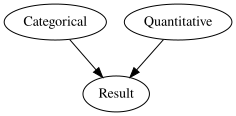

In [ ]:
dag_1 = gv.Digraph(comment='model1')

dag_1.node('G', 'Result')
dag_1.node('T','Categorical')
dag_1.node('P','Quantitative')

dag_1.edges(['TG','PG',])

dag_1

The model described by the causal diagram above might have a tendency to overfit. This is because there are multiple priors. Nonetheless, this would be a valid model.

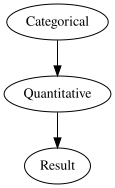

In [ ]:
dag_2 = gv.Digraph(comment='model2')

dag_2.node('G', 'Result')
dag_2.node('T','Categorical')
dag_2.node('P','Quantitative')

dag_2.edges(['TP','PG',])

dag_2

The structure of the model above mimics a heirarchy. This means that there is effectively 1 prior and 1 hyperprior, which tends to have high accuracy. The model probably won't overfit and be very promising.

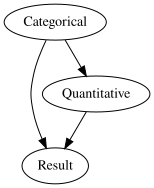

In [ ]:
dag_3 = gv.Digraph(comment='model3')

dag_3.node('G', 'Result')
dag_3.node('T','Categorical')
dag_3.node('P','Quantitative')

dag_3.edges(['TG','PG','TP'])

dag_3

This has a similar structure to the previous model except it uses the categorical variable as both a prior and and a hyperprior for the quantitative prior. I think this would perform well since it's making the most of the assumptions you have about the data-- but I feel like it's doing too much.

**Task9**:

How do we visualize multiple linear regression models? Can we visualize the entire model, all at once?

You can use the plot_predictions method in the bambi library which creates multiple regressions. The method will create a linear regression model across all of the categorical variables which is just plotting all of the possible regressions given your data!

**Task10**:

Compare the following linear models that all use the basketball data to predict field goal percentage:

- predictors free throw percentage and position (with position as a categorical predictor)
- predictors free throw percentage and position (with position as a hierarchy)
- predictors free throw percentage and position (with position interacting with frew throw percentage)
- predictors free throw percentage, position, 3 point attempts, and interactions between all three predictors
- predictors free throw percentage, position, 3 point attempts, with an interaction between 3 point attempts and postion.

using ```az.compare()``` and ```az.plot_compare()```, or an equivalent method using LOO (elpd_loo).

You may use the following two code blocks to load and clean the data.

In [ ]:
#have to drop incomplete rows, so that bambi will run
bb = pd.read_csv(
    'https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/basketball2324.csv'
    ).dropna()

In [ ]:
#only look at players who played more than 600 minutes
#which is 20 min per game, for 30 games
bb = bb.query('MP > 600')
#remove players who never missed a free throw
bb = bb.query('`FT%` != 1.0')
#filter out the combo positions. This will make it easier to read the graphs
bb = bb.query("Pos in ['C','PF','SF','SG','PG']")
#gets rid of the annoying '%' sign
bb.rename(columns={"FT%":"FTp","FG%":"FGp"}, inplace=True)

In [ ]:
model_1 = bmb.Model("FGp ~ FTp + Pos", data=bb)
idata_1 = model_1.fit(idata_kwargs={'log_likelihood': True})

Output()

(<Figure size 1100x400 with 1 Axes>,
 array([<Axes: xlabel='FTp', ylabel='FGp'>], dtype=object))

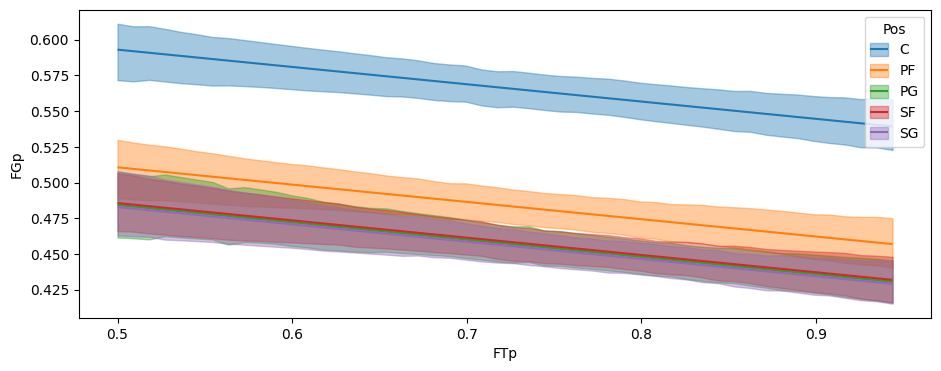

In [ ]:
bmb.interpret.plot_predictions(model_1,
                               idata_1,
                               ["FTp","Pos"],
                               fig_kwargs={"figsize":(11, 4)})

In [ ]:
model_2 = bmb.Model("FGp ~ (FTp|Pos)", data=bb)
idata_2 = model_2.fit(idata_kwargs={'log_likelihood': True})

Output()

ERROR:pymc.stats.convergence:There were 19 divergences after tuning. Increase `target_accept` or reparameterize.


(<Figure size 1100x400 with 1 Axes>,
 array([<Axes: xlabel='FTp', ylabel='FGp'>], dtype=object))

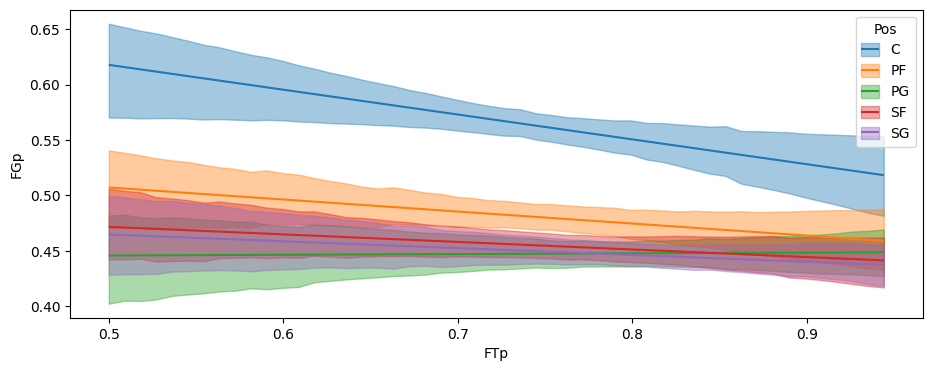

In [ ]:
bmb.interpret.plot_predictions(model_2,
                               idata_2,
                               ["FTp","Pos"],
                               fig_kwargs={"figsize":(11, 4)})

In [ ]:
#define the model; bb_inter stands for baskeball interaction
model_bb_inter = bmb.Model("`FGp` ~ `FTp` + `FTp`:Pos", data=bb)
#create the model
idata_bb_inter = model_bb_inter.fit(idata_kwargs={'log_likelihood': True})

Output()

(<Figure size 1100x400 with 1 Axes>,
 array([<Axes: xlabel='FTp', ylabel='FGp'>], dtype=object))

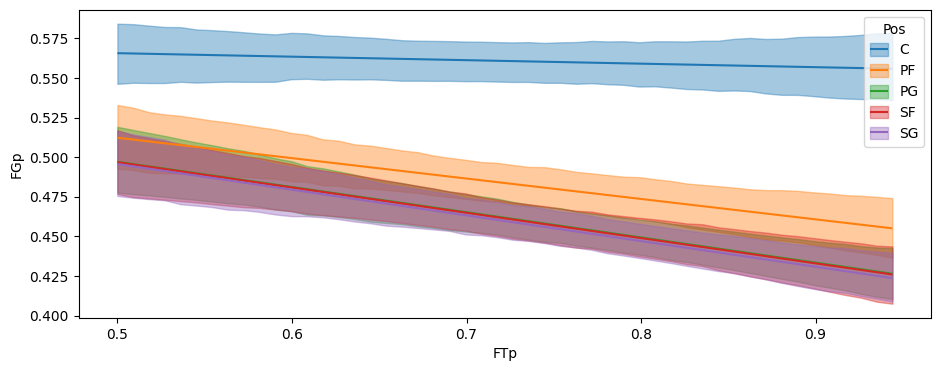

In [ ]:
bmb.interpret.plot_predictions(model_bb_inter,
                               idata_bb_inter,
                               ["FTp","Pos"],
                               fig_kwargs={"figsize":(11, 4)})

In [ ]:
#define the model; bb_inter stands for baskeball interaction
model_4 = bmb.Model("FGp ~ FTp + `3PA` + FTp:`3PA`", data=bb)
#create the model
idata_4 = model_4.fit(idata_kwargs={'log_likelihood': True})

Output()

In [ ]:
model_4 = bmb.Model("FGp ~ FTp + `3PA` + Pos + Pos:`3PA` + FTp:`3PA`", data=bb)
idata_4 = model_4.fit(idata_kwargs={'log_likelihood': True})

Output()

(<Figure size 1100x400 with 1 Axes>,
 array([<Axes: xlabel='FTp', ylabel='FGp'>], dtype=object))

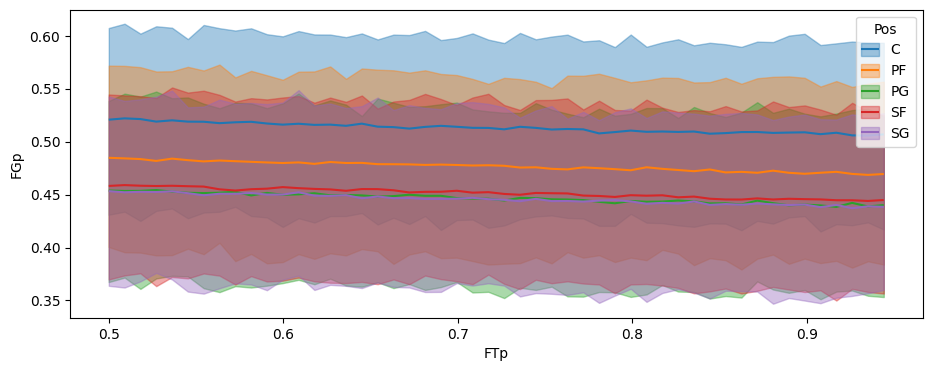

In [ ]:
bmb.interpret.plot_predictions(model_4,
                               idata_4,
                               ["FTp","Pos"],
                               fig_kwargs={"figsize":(11, 4)}, pps=True)

In [ ]:
# predictors free throw percentage, position, 3 point attempts, with an interaction between 3 point attempts and position

#define the model;
model_5 = bmb.Model("`FGp` ~ `FTp` + `3PA` + Pos + `3PA`:Pos ", data=bb)
#create the model
idata_5 = model_5.fit(idata_kwargs={'log_likelihood': True})

Output()

(<Figure size 1100x400 with 1 Axes>,
 array([<Axes: xlabel='FTp', ylabel='FGp'>], dtype=object))

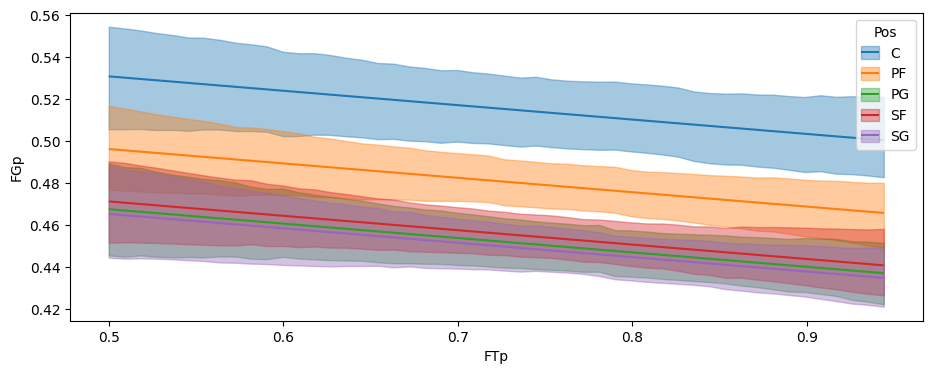

In [ ]:
bmb.interpret.plot_predictions(model_5,
                               idata_5,
                               ["FTp","Pos"],
                               fig_kwargs={"figsize":(11, 4)})

In [ ]:
# predictors free throw percentage, position, 3 point attempts, and interactions between all three predictors
model_6 = bmb.Model("FGp ~ FTp + `3PA` + Pos + FTp:`3PA` + FTp:Pos + `3PA`:Pos", data=bb)
idata_6 = model_6.fit(idata_kwargs={'log_likelihood': True})

Output()

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


                rank    elpd_loo      p_loo  elpd_diff        weight  \
model_4            0  532.947520  13.821255   0.000000  7.974176e-01   
model_5            1  529.977387  12.693309   2.970134  2.025824e-01   
model_6            2  528.405327  19.824803   4.542193  1.117547e-13   
model_2            3  508.081832  14.145263  24.865688  8.793903e-14   
model_1            4  507.159139   8.452740  25.788381  7.110101e-14   
model_bb_inter     5  500.129066   8.484640  32.818455  0.000000e+00   

                       se       dse  warning scale  
model_4         15.030902  0.000000     True   log  
model_5         15.915579  3.290586    False   log  
model_6         15.148408  1.662029     True   log  
model_2         17.120177  7.134336    False   log  
model_1         16.117286  7.103981    False   log  
model_bb_inter  16.244285  8.526093    False   log  


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

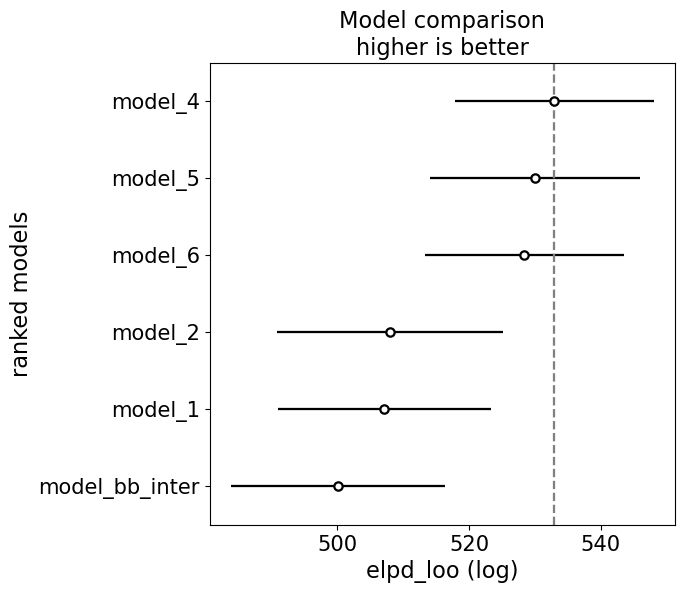

In [ ]:
models = {"model_1": idata_1, "model_2": idata_2, "model_bb_inter": idata_bb_inter, "model_4": idata_4, "model_5": idata_5, "model_6": idata_6}
df_compare = az.compare(models)
print(df_compare)

az.plot_compare(df_compare, insample_dev=False)

**Task11**:

Which model is "better" according to this metric?

Why do you think that is?

I think that model 4 is the best one because

**Task12:**

The body data set has a measure of body fat percentage (siri), as well as several other measurments of other parts of a person's body, plus their age.

Create a sensible causal diagram for this set of variables.

Based on your causal diagram, which variable should you try to predict? Why?

In [ ]:
body = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/body_fat.csv')

In [ ]:
body.head()

,siri,age,weight,height,abdomen,thigh,wrist
0,12.3,23,70.1,172,85.2,59.0,17.1
1,6.1,22,78.8,184,83.0,58.7,18.2
2,25.3,22,70.0,168,87.9,59.6,16.6
3,10.4,26,84.0,184,86.4,60.1,18.2
4,28.7,24,83.8,181,100.0,63.2,17.7


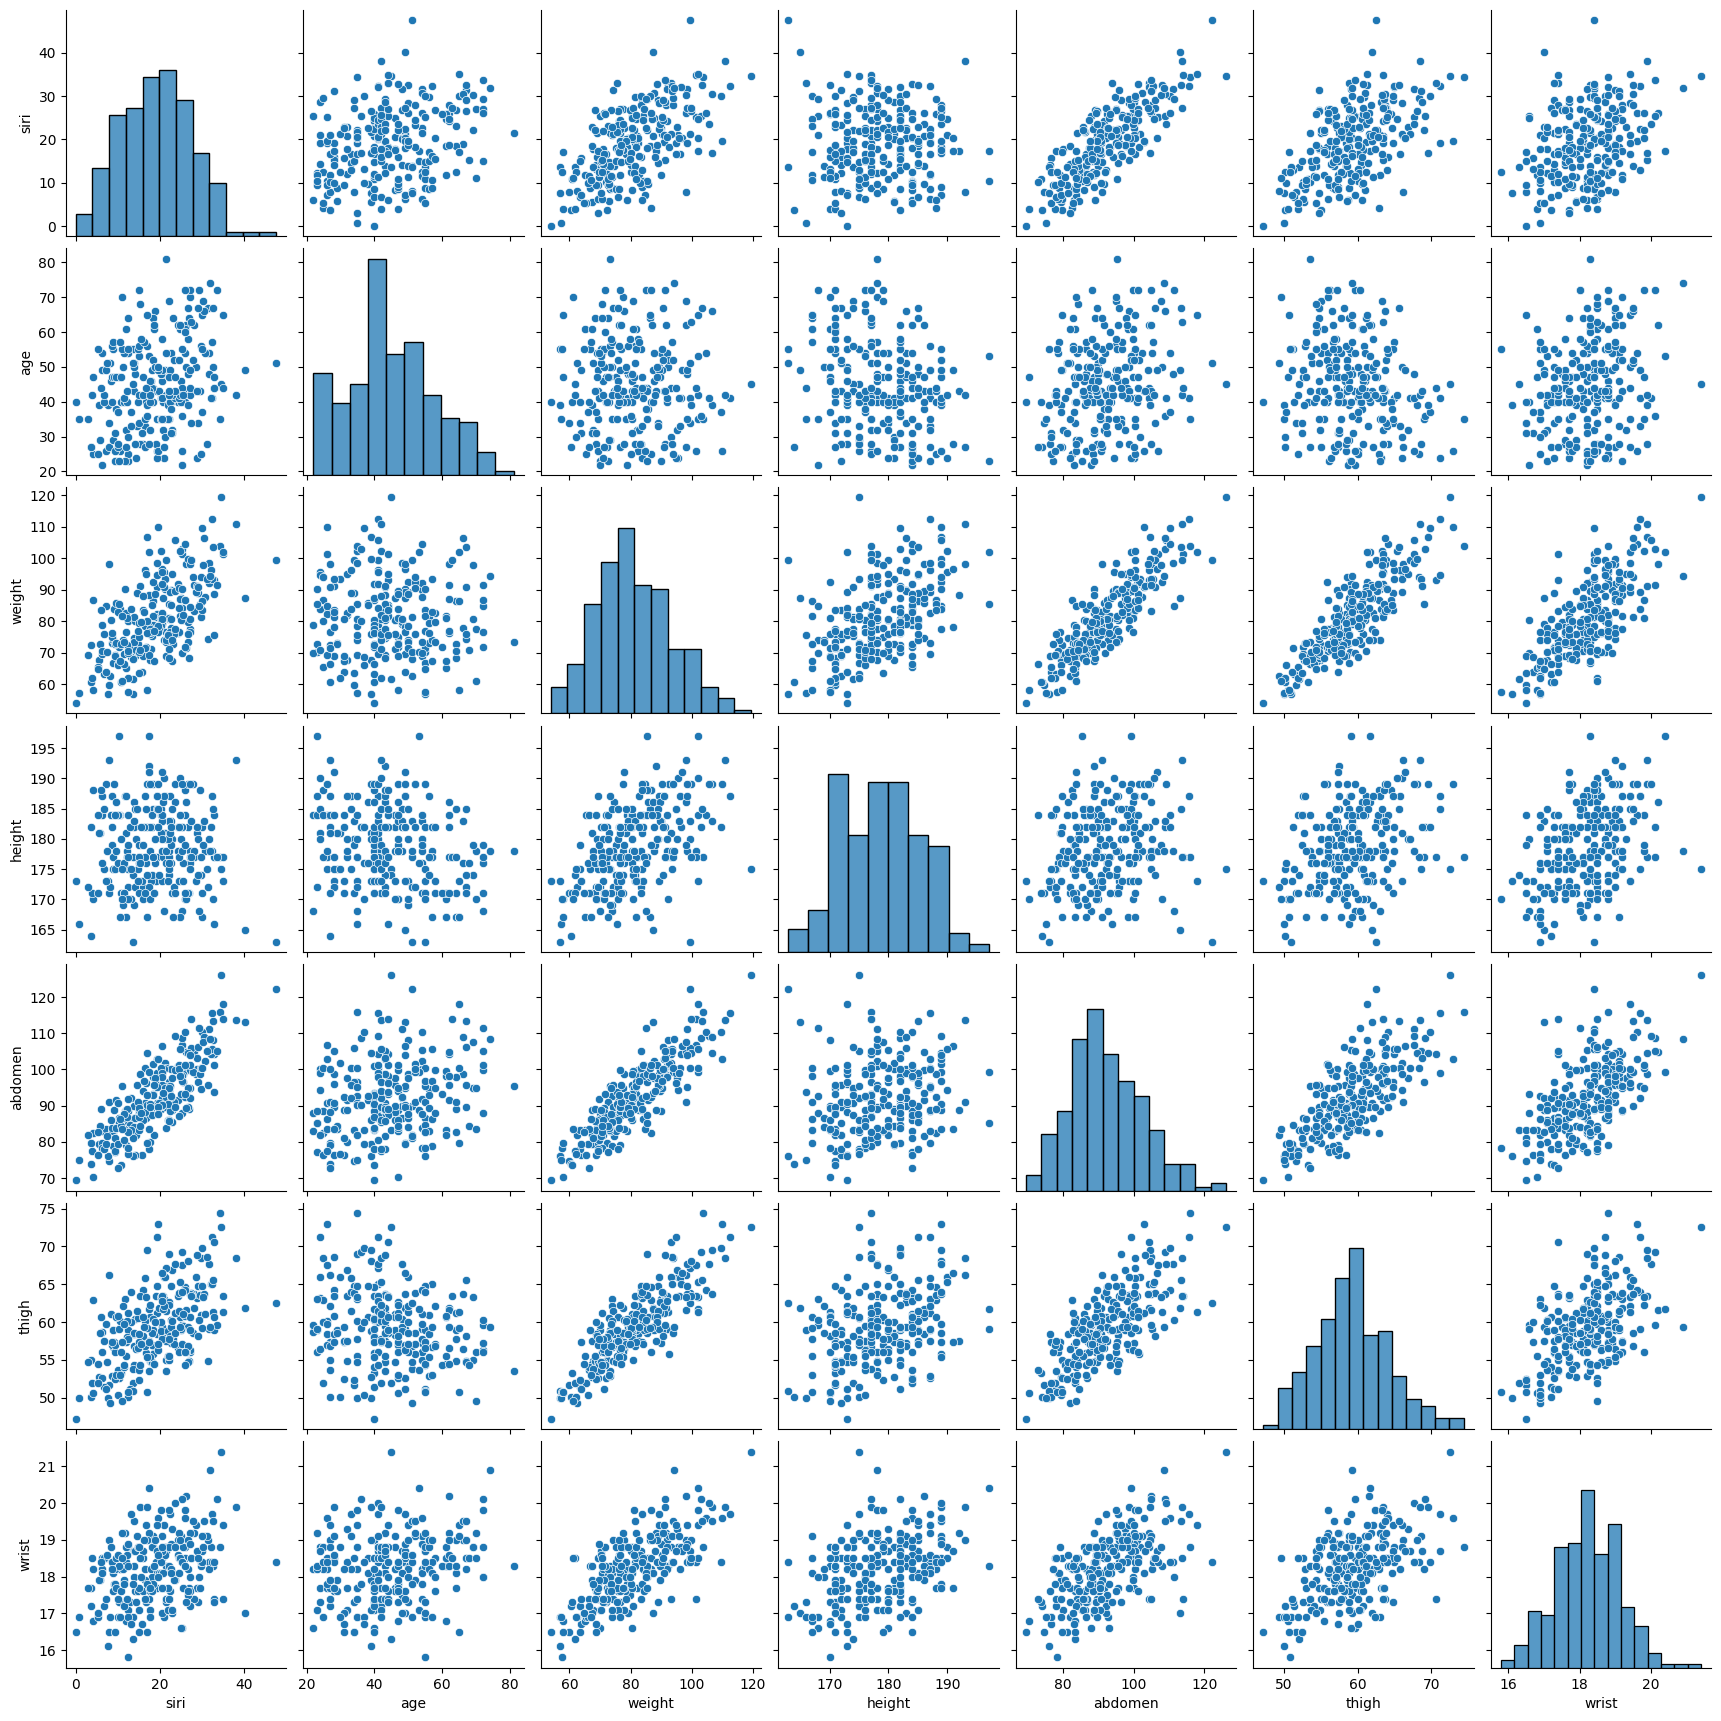

In [ ]:
sns.pairplot(body)

After taking of note of some of the stronrg linear relationships, I identified a couple of data points that would need to be a part of my DAG. I found that height wasn't strong enough to have an impact on any of the variables so it won't show up on my causal diagram.

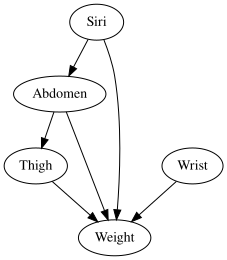

In [ ]:
dag_weight = gv.Digraph(comment='siri')

dag_weight.node('A', 'Siri')
dag_weight.node('B', 'Abdomen')
dag_weight.node('C','Thigh')
dag_weight.node('D','Wrist')
dag_weight.node('E', 'Weight')

dag_weight.edges(['AB','BC','BE', 'CE', 'DE', 'AE'])

dag_weight

I am going to predict weight because abdomen, thigh, and wrist measurements have a direct relation to weight. I found that there is a strong relation between siri (body fat %) and abdomen but not really any of the other variables. There are a lot of variables that have strong ties to weight so it's best to predict that because there is so much connection to it.